<a href="https://colab.research.google.com/github/bisu617/ai-misinformation-detection/blob/main/model-stage1/Bert_Uncased.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: Install libraries
# ============================================================
!pip install -q datasets transformers accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00


In [ ]:
# ============================================================
# CELL 2: Check GPU
# ============================================================
import torch
print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

CUDA available: True
Device: Tesla T4


In [ ]:
# ============================================================
# CELL 3: Load Dataset from HuggingFace
# ============================================================
from datasets import load_dataset

dataset = load_dataset("artem9k/ai-text-detection-pile")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['source', 'id', 'text'],
        num_rows: 1392522
    })
})


In [ ]:
# ============================================================
# CELL 4: Save to Disk (so you don't re-download next time)
# ============================================================
dataset.save_to_disk("ai_text_detection_pile")


# ============================================================
# CELL 5: Sample 100K train + 10K test
# ============================================================
from datasets import load_from_disk
import re

ds_full = load_from_disk("ai_text_detection_pile")["train"].shuffle(seed=123)

train_part = ds_full.select(range(100_000))
val_part   = ds_full.select(range(100_000, 110_000))
test_part  = ds_full.select(range(110_000, 120_000))

print('Train:', len(train_part))
print('Val:  ', len(val_part))
print('Test: ', len(test_part))

Saving the dataset (0/7 shards):   0%|          | 0/1392522 [00:00<?, ? examples/s]

Train: 100000
Val:   10000
Test:  10000


In [ ]:
# ============================================================
# CELL 6: Clean Text
# ============================================================
def clean_text(ex):
    t = ex["text"]
    if t is None:
        t = ""
    t = str(t)
    ex["text"] = re.sub(r"\s+", " ", t).strip()
    return ex

train_part = train_part.map(clean_text)
val_part   = val_part.map(clean_text)
test_part  = test_part.map(clean_text)

train_part = train_part.filter(lambda x: len(x["text"]) >= 30)
val_part   = val_part.filter(lambda x: len(x["text"]) >= 30)
test_part  = test_part.filter(lambda x: len(x["text"]) >= 30)

print('After cleaning:')
print('Train:', len(train_part))
print('Val:  ', len(val_part))
print('Test: ', len(test_part))

After cleaning:
Train: 99916
Val:   9988
Test:  9990


In [ ]:
# ============================================================
# CELL 7: Label Encoding
# ============================================================
label2id = {"human": 0, "ai": 1}
id2label = {0: "human", 1: "ai"}

def encode_label(ex):
    return {"label": label2id[ex["source"]]}

train_part = train_part.map(encode_label)
val_part   = val_part.map(encode_label)
test_part  = test_part.map(encode_label)

# Keep only text and label columns
cols_to_keep = ["text", "label"]
train_part = train_part.remove_columns([c for c in train_part.column_names if c not in cols_to_keep])
val_part   = val_part.remove_columns([c for c in val_part.column_names if c not in cols_to_keep])
test_part  = test_part.remove_columns([c for c in test_part.column_names if c not in cols_to_keep])

print('Labels encoded!')
print(train_part)

Labels encoded!
Dataset({
    features: ['text', 'label'],
    num_rows: 99916
})


In [ ]:
# ============================================================
# CELL 8: Tokenize
# ============================================================
from transformers import AutoTokenizer

model_name = 'bert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=128, padding='max_length')

train_tok = train_part.map(tokenize, batched=True, remove_columns=['text'])
val_tok   = val_part.map(tokenize,   batched=True, remove_columns=['text'])
test_tok  = test_part.map(tokenize,  batched=True, remove_columns=['text'])

train_tok.set_format('torch')
val_tok.set_format('torch')
test_tok.set_format('torch')

print('Tokenization done!')

Map:   0%|          | 0/9988 [00:00<?, ? examples/s]

Tokenization done!


In [ ]:
# ============================================================
# CELL 9: Load Model + Define Metrics
# ============================================================
import numpy as np
import evaluate
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

acc_metric = evaluate.load('accuracy')
f1_metric  = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': acc_metric.compute(predictions=preds, references=labels)['accuracy'],
        'f1':       f1_metric.compute(predictions=preds,  references=labels, average='binary')['f1']
    }

print('Model loaded!')

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!


In [ ]:
# ============================================================
# CELL 10: Training Arguments + Trainer
# ============================================================
args = TrainingArguments(
    output_dir='roberta_stage1',
    eval_strategy='steps',
    eval_steps=500,
    save_steps=500,
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=False,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    report_to='none'
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
torch.cuda.empty_cache()

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
# ============================================================
# CELL 11: Train
# Watch Train Loss vs Val Loss in the table
# val_loss going UP while train_loss goes DOWN = overfitting
# ============================================================
train_result = trainer.train()
print('\nTraining complete!')
print(f"Total train time : {train_result.metrics['train_runtime']:.1f}s")
print(f"Train samples/sec: {train_result.metrics['train_samples_per_second']:.1f}")

Step,Training Loss,Validation Loss,Accuracy,F1
500,0.207634,0.174989,0.934521,0.876371
1000,0.164006,0.201492,0.913296,0.854795
1500,0.155148,0.199228,0.927913,0.876204
2000,0.163626,0.139588,0.947437,0.904840
2500,0.141974,0.402838,0.897677,0.835480
3000,0.128803,0.141734,0.946936,0.905222
3500,0.118974,0.170551,0.941029,0.896540
4000,0.133844,0.165249,0.943132,0.898571
4500,0.113436,0.131329,0.957249,0.922208
5000,0.122153,0.157406,0.946336,0.905166


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training complete!
Total train time : 10450.7s
Train samples/sec: 28.7


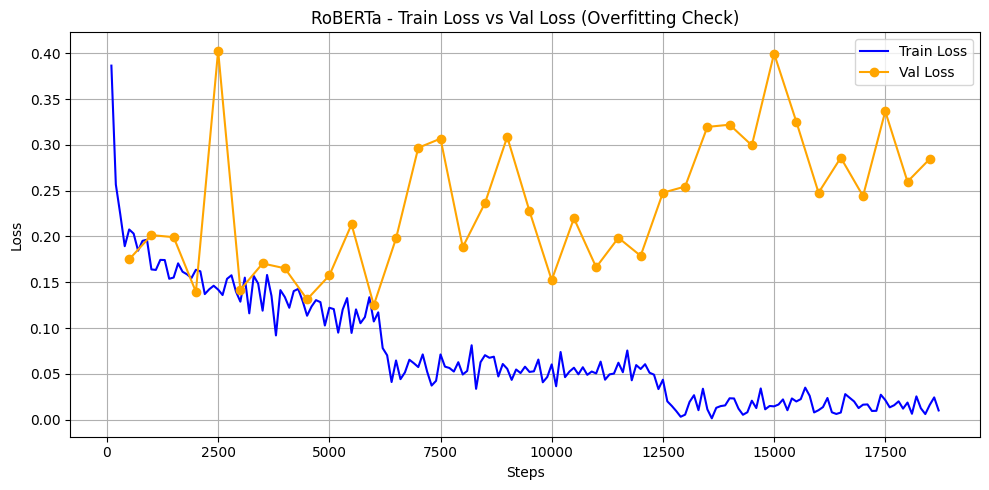

Overfitting plot done!


In [ ]:
# ============================================================
# CELL 12: Overfitting Plot
# ============================================================
import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_steps  = [x['step'] for x in logs if 'loss' in x and 'eval_loss' not in x]
train_losses = [x['loss'] for x in logs if 'loss' in x and 'eval_loss' not in x]
val_steps    = [x['step'] for x in logs if 'eval_loss' in x]
val_losses   = [x['eval_loss'] for x in logs if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_losses, label='Train Loss', color='blue')
plt.plot(val_steps,   val_losses,   label='Val Loss',   color='orange', marker='o')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('RoBERTa - Train Loss vs Val Loss (Overfitting Check)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print('Overfitting plot done!')


In [ ]:
# ============================================================
# CELL 13: Final Test Evaluation (F1 + Accuracy)
# ============================================================
test_results = trainer.evaluate(test_tok)
print('\n========== FINAL TEST RESULTS ==========')
print(f"Accuracy : {test_results['eval_accuracy']:.4f}")
print(f"F1 Score : {test_results['eval_f1']:.4f}")
print(f"Eval Loss: {test_results['eval_loss']:.4f}")
print('=========================================')



========== FINAL TEST RESULTS ==========
Accuracy : 0.9603
F1 Score : 0.9298
Eval Loss: 0.1663



=== Classification Report ===
              precision    recall  f1-score   support

       Human       0.99      0.95      0.97      7309
          AI       0.88      0.98      0.93      2681

    accuracy                           0.96      9990
   macro avg       0.94      0.97      0.95      9990
weighted avg       0.96      0.96      0.96      9990



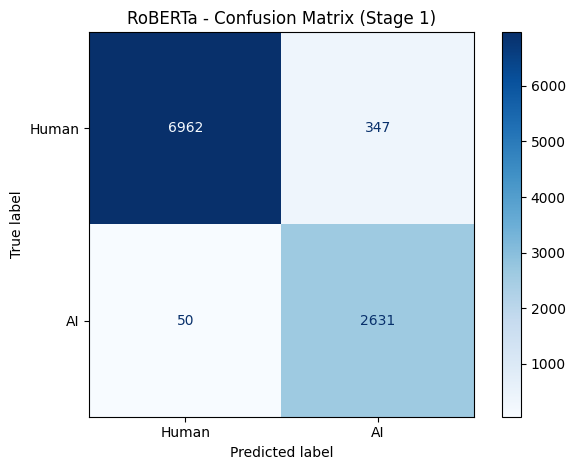

Confusion matrix done!


In [ ]:
# ============================================================
# CELL 14: Confusion Matrix + Classification Report
# ============================================================
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

preds_output = trainer.predict(test_tok)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=['Human', 'AI']))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'AI'])
disp.plot(cmap='Blues')
plt.title('RoBERTa - Confusion Matrix (Stage 1)')
plt.tight_layout()
plt.show()
print('Confusion matrix done!')

In [ ]:
# ============================================================
# CELL 15: Save Model
# ============================================================
trainer.save_model("roberta_stage1_model")
tokenizer.save_pretrained("roberta_stage1_model")
print('Model saved!')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved!
